In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"
df = pd .read_csv(url,header=None,names=["label_id","title","description"])
df.head(5)

,label_id,title,description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [ ]:
df.describe()

,label_id
count,7600.000000
mean,2.500000
std,1.118108
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label_id     7600 non-null   int64 
 1   title        7600 non-null   object
 2   description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [ ]:
print(df['label_id'].unique())

[3 4 2 1]


In [ ]:
sample_rows = df.groupby('label_id').first().reset_index()
print(sample_rows)

   label_id                                              title  \
0         1  Sister of man who died in Vancouver police cus...   
1         2           Giddy Phelps Touches Gold for First Time   
2         3                  Fears for T N pension after talks   
3         4  The Race is On: Second Private Team Sets Launc...   

                                         description  
0  Canadian Press - VANCOUVER (CP) - The sister o...  
1  Michael Phelps won the gold medal in the 400 i...  
2  Unions representing workers at Turner   Newall...  
3  SPACE.com - TORONTO, Canada -- A second\team o...  


In [ ]:
label_map = {1: "World" , 2: "Sport" , 3: "Business" , 4: "Sci/Tech"}
df["category"] = df["label_id"].map(label_map)

print("Dataset shape" , df.shape)
print(df[["category", "title", "description"]].head(3))

Dataset shape (7600, 4)
   category                                              title  \
0  Business                  Fears for T N pension after talks   
1  Sci/Tech  The Race is On: Second Private Team Sets Launc...   
2  Sci/Tech      Ky. Company Wins Grant to Study Peptides (AP)   

                                         description  
0  Unions representing workers at Turner   Newall...  
1  SPACE.com - TORONTO, Canada -- A second\team o...  
2  AP - A company founded by a chemistry research...  


In [ ]:
df.isnull().sum()


,0
label_id,0
title,0
description,0
category,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["char_count"] = df['description'].apply(len)

In [ ]:
df['word_count'] = df['description'].apply(lambda x : len(x.split()))

In [ ]:
df.head()

,label_id,title,description,category,char_count,word_count
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...,Business,127,18
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",Sci/Tech,234,34
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Sci/Tech,214,37
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Sci/Tech,272,49
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Sci/Tech,179,27


In [ ]:
df.describe()

,label_id,char_count,word_count
count,7600.000000,7600.000000,7600.000000
mean,2.500000,192.408026,30.963289
std,1.118108,63.192774,9.803751
min,1.000000,37.000000,4.000000
25%,1.750000,154.000000,25.000000
50%,2.500000,187.000000,30.000000
75%,3.250000,218.000000,36.000000
max,4.000000,830.000000,129.000000


In [ ]:
print(df.loc[df["word_count"].idxmin()])

label_id                                                       4
title              Clarke takes charge of Blunkett's Fear Agenda
description    &lt;strong&gt;Analysis&lt;/strong&gt; Horizont...
category                                                Sci/Tech
char_count                                                    65
word_count                                                     4
Name: 7461, dtype: object


In [ ]:
print(df["description"].str.contains("<",regex=False).sum())
print(df["description"].str.contains("&",regex=False).sum())
print(df["description"].str.contains("http",regex=False).sum())

0
151
99


In [ ]:
import re
import html

df['description'] = df['description'].apply(html.unescape)
df['description'] = df['description'].apply(lambda x : re.sub(r"<[^>]+>","",str(x)))
#ypu can either use the above method to replace the tags or use the inbuilt str.replace function
#df['description'] = df['description].str.replace(r"<[^>]+>","",regex=True)
df['description'] = df['description'].str.replace(r"https?://\S+|www\.\S+","",regex = True)

NLTK PROCESSING


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # 1. Lowercase and remove punctuation/special characters
    text = re.sub(r"[^a-zA-Z\s]", "", str(text)).lower()

    # 2. Tokenize
    tokens = word_tokenize(text)

    # 3. Filter out stopwords and short tokens (< 2 chars), then lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    # 4. Join back into a single clean string
    return " ".join(cleaned_tokens)

df['description'] = df['description'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df.head()

,label_id,title,description,category,char_count,word_count
0,3,Fears for T N pension after talks,union representing worker turner newall say di...,Business,127,18
1,4,The Race is On: Second Private Team Sets Launc...,spacecom toronto canada secondteam rocketeers ...,Sci/Tech,234,34
2,4,Ky. Company Wins Grant to Study Peptides (AP),company founded chemistry researcher universit...,Sci/Tech,214,37
3,4,Prediction Unit Helps Forecast Wildfires (AP),barely dawn mike fitzpatrick start shift blur ...,Sci/Tech,272,49
4,4,Calif. Aims to Limit Farm-Related Smog (AP),southern california smogfighting agency went e...,Sci/Tech,179,27


In [ ]:
all_words = []

for text in df["description"]:
    all_words.extend(text.split())

unique_words = set(all_words)

print("Total words:", len(all_words))
print("Unique words:", len(unique_words))

Total words: 143429
Unique words: 19508


In [ ]:
from collections import Counter
word_freq = Counter(all_words)
print(word_freq.most_common(20))

[('said', 1288), ('new', 1061), ('reuters', 790), ('year', 709), ('company', 623), ('two', 537), ('first', 535), ('monday', 495), ('tuesday', 487), ('world', 451), ('one', 449), ('thursday', 447), ('wednesday', 444), ('inc', 442), ('friday', 406), ('state', 388), ('week', 382), ('last', 374), ('york', 370), ('game', 355)]


In [ ]:
print(df['category'].value_counts())

category
Business    1900
Sci/Tech    1900
Sport       1900
World       1900
Name: count, dtype: int64


In [ ]:
for category in df['category'].unique():
  text = "".join(
      df[df['category']==category]['description']
  )
  words = text.split()
  freq = Counter(words)
  print(f"\n{category}")
  print(freq.most_common(10))



Business
[('said', 428), ('company', 300), ('reuters', 262), ('inc', 257), ('price', 223), ('oil', 209), ('york', 196), ('year', 195), ('new', 181), ('percent', 165)]

Sci/Tech
[('new', 280), ('company', 244), ('said', 227), ('software', 163), ('year', 162), ('service', 162), ('internet', 156), ('microsoft', 146), ('computer', 142), ('system', 141)]

Sport
[('game', 240), ('first', 228), ('team', 207), ('win', 178), ('season', 170), ('one', 167), ('last', 166), ('world', 161), ('two', 161), ('league', 151)]

World
[('said', 342), ('president', 225), ('iraq', 206), ('minister', 187), ('people', 165), ('reuters', 163), ('two', 163), ('official', 158), ('killed', 141), ('leader', 140)]


Text representation/Vector encodings / Cosine similarity


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['description'])
print("Vocabulary size:", len(vectorizer.vocabulary_))
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:20])
X.shape

Vocabulary size: 19508
['aakash' 'aan' 'aapl' 'aaplo' 'aaron' 'aba' 'ababa' 'abandon' 'abandoned'
 'abare' 'abarrel' 'abb' 'abbas' 'abbey' 'abbott' 'abc' 'abd' 'abdicate'
 'abdication' 'abdominal']


(7600, 19508)

In [ ]:
texts = [
    "microsoft releases new software",
    "google launches new software",
    "football team wins championship"
]

vectorizer = CountVectorizer()

matrix = vectorizer.fit_transform(texts)

print(pd.DataFrame(
    matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
))

   championship  football  google  launches  microsoft  new  releases  \
0             0         0       0         0          1    1         1   
1             0         0       1         1          0    1         0   
2             1         1       0         0          0    0         0   

   software  team  wins  
0         1     0     0  
1         1     0     0  
2         0     1     1  


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
vectorizer = CountVectorizer()
sample_docs = df['description'].head(5)
print(sample_docs)
X = vectorizer.fit_transform(sample_docs)

0    union representing worker turner newall say di...
1    spacecom toronto canada secondteam rocketeers ...
2    company founded chemistry researcher universit...
3    barely dawn mike fitzpatrick start shift blur ...
4    southern california smogfighting agency went e...
Name: description, dtype: object


In [ ]:
similarity_matrix = cosine_similarity(X)
print(similarity_matrix)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embedding = model.encode(df['description'].tolist(),
                         show_progress_bar=True)
print(embedding.shape)

Batches:   0%|          | 0/238 [00:00<?, ?it/s]

(7600, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

article_idx = 0

similarities = cosine_similarity(
    [embedding[article_idx]],
    embedding
)[0]

top_indices = similarities.argsort()[-6:][::-1]

for idx in top_indices:
    print("\nSimilarity:", round(similarities[idx], 4))
    print("Category:", df.iloc[idx]["category"])
    print("Text:", df.iloc[idx]["description"][:200])
    print("-" * 100)


Similarity: 1.0
Category: Business
Text: union representing worker turner newall say disappointed talk stricken parent firm federal mogul
----------------------------------------------------------------------------------------------------

Similarity: 0.4205
Category: Business
Text: federalmogul corp bankrupt engineering company may sell ukbased turner amp newall plc division independent pension trustee rejected million cash offer
----------------------------------------------------------------------------------------------------

Similarity: 0.4124
Category: Business
Text: labor expert say unite newly merged union representing hotel worker current contract dispute one outspoken toughest union aflcio umbrella
----------------------------------------------------------------------------------------------------

Similarity: 0.3716
Category: Business
Text: union leader representing pilot american eagle commuter division american airline accepted tentative contract agreement includes pay r

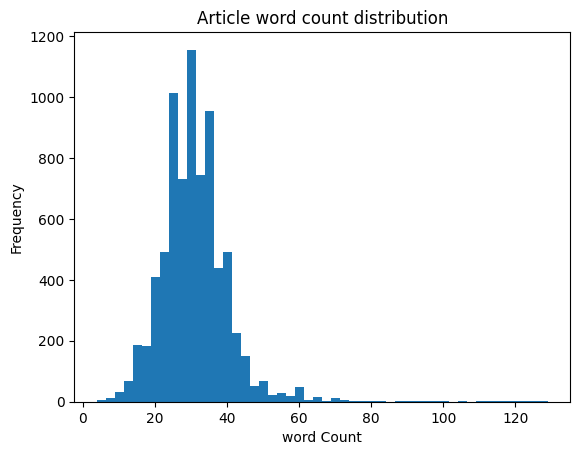

In [ ]:
#IQR
plt.figsize=(10,5)
plt.hist(df['word_count'],bins=50)
plt.title("Article word count distribution")
plt.xlabel("word Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1- 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower bound:",lower_bound)
print("Upper bound:",upper_bound)

Q1: 25.0
Q3: 36.0
IQR: 11.0
Lower bound: 8.5
Upper bound: 52.5


In [ ]:
outliers = df[
    (df["word_count"] < lower_bound)
    | (df["word_count"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 197
